# Retail Sales Analysis Project

## Objective
This project analyzes retail sales data to identify key business trends, customer behavior, and product performance to support data-driven decision making.

## Dataset Overview
The dataset contains retail transactions including sales, profit, discount, customer segments, regions, and product details.

Data Loading

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [159]:
data = pd.read_csv('sample.csv', encoding='latin1')

# Quick preview
data.head()

data.shape

(9994, 21)

Data Cleaning & Preparation

In [160]:
# Convert date columns to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], errors='coerce')

# Missing values overview
missing = data.isnull().sum()

In [161]:
# Create a monthly period column for time series grouping
data['Month'] = data['Order Date'].dt.to_period('M')

Exploratory Data Analysis (EDA)

Category Analysis

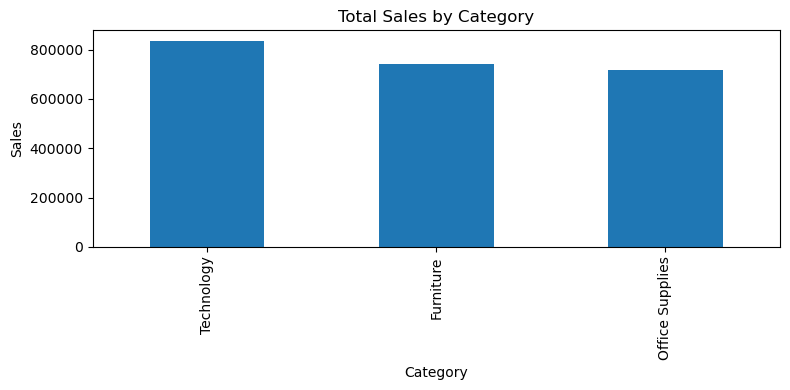

In [162]:
# Total Sales by Category
sales_by_cat = data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
ax = sales_by_cat.plot(kind='bar', figsize=(8,4))
ax.set_title('Total Sales by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Sales')
plt.tight_layout()
plt.show()

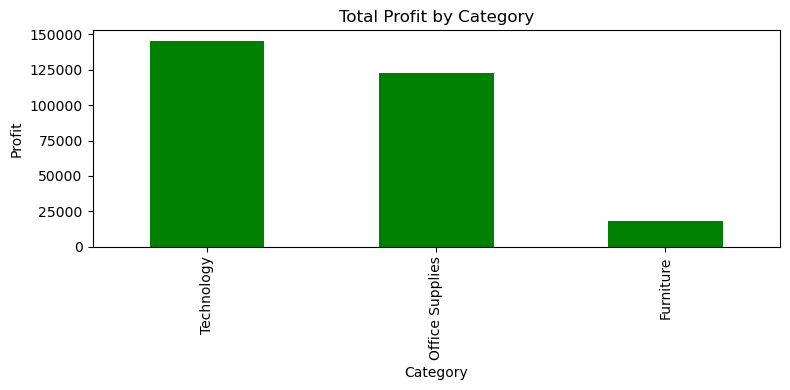

In [163]:
# Total Profit by Category
profit_by_cat = data.groupby('Category')['Profit'].sum().sort_values(ascending=False)
ax = profit_by_cat.plot(kind='bar', color='green', figsize=(8,4))
ax.set_title('Total Profit by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()

Segment Analysis

In [164]:
seg_sales = data.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
seg_profit = data.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
display(seg_sales.to_frame('Total Sales'))
display(seg_profit.to_frame('Total Profit'))

,Total Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


,Total Profit
Segment,
Consumer,134119.2092
Corporate,91979.1340
Home Office,60298.6785


Region Analysis

In [165]:
region_perf = data.groupby('Region')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)
display(region_perf)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


Sub-Category Analysis

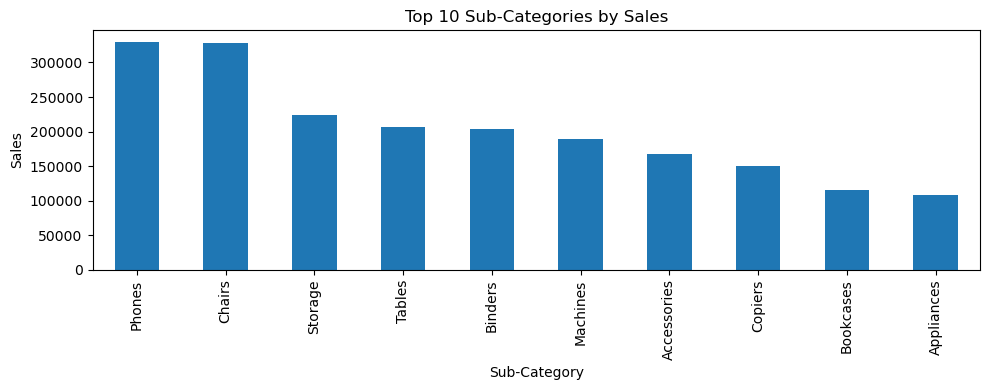

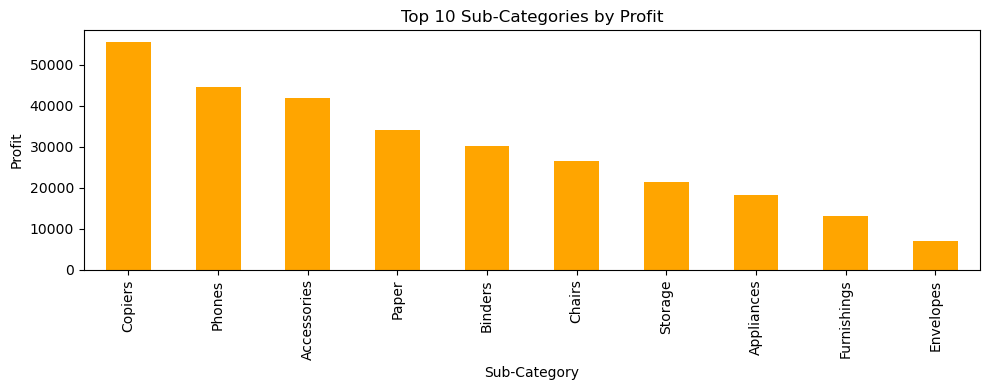

In [166]:
# Top sub-categories by Sales
top_sub_sales = data.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
ax = top_sub_sales.head(10).plot(kind='bar', figsize=(10,4))
ax.set_title('Top 10 Sub-Categories by Sales')
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Sales')
plt.tight_layout()
plt.show()

# Top sub-categories by Profit
top_sub_profit = data.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
ax = top_sub_profit.head(10).plot(kind='bar', color='orange', figsize=(10,4))
ax.set_title('Top 10 Sub-Categories by Profit')
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()

Time Series Analysis

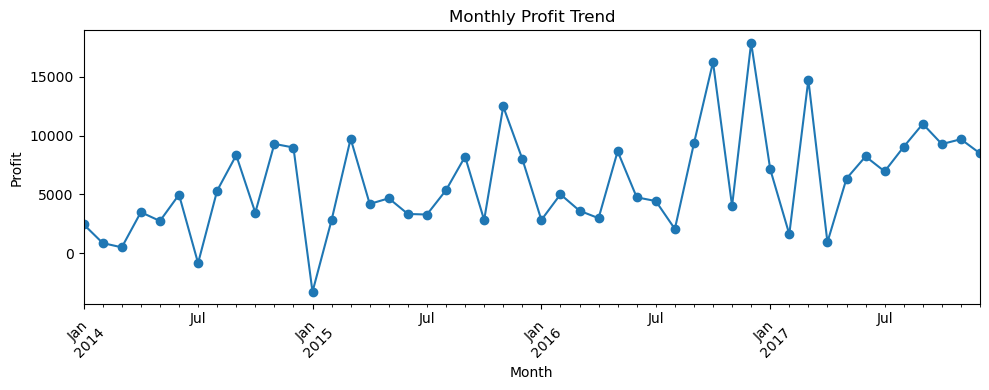

In [167]:
monthly_profit = data.groupby('Month')['Profit'].sum().sort_index()
ax = monthly_profit.plot(kind='line', marker='o', figsize=(10,4))
ax.set_title('Monthly Profit Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product Analysis

In [168]:
top_products = data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
display(top_products.to_frame('Total Sales'))

,Total Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


Discount vs Profit Analysis

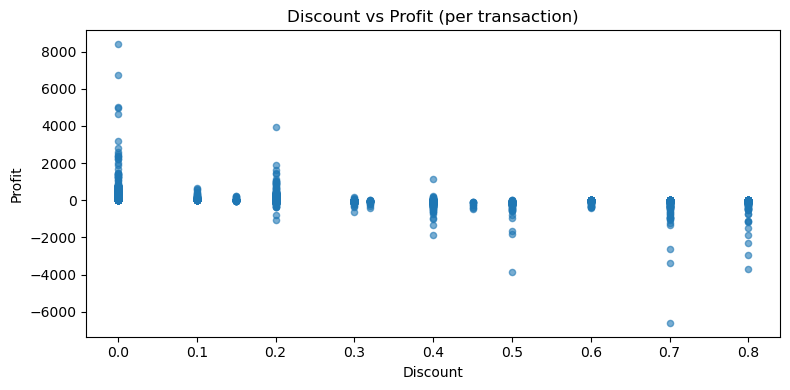

Discount vs Profit correlation: -0.219


In [169]:
# Scatter plot: Discount vs Profit
ax = data.plot.scatter(x='Discount', y='Profit', alpha=0.6, figsize=(8,4))
ax.set_title('Discount vs Profit (per transaction)')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()

# Correlation
corr = data['Discount'].corr(data['Profit'])
print(f'Discount vs Profit correlation: {corr:.3f}')

# Key Insights

## 1. Category Performance
Technology products generated the highest sales and profit, indicating strong demand for tech-related items compared to Furniture and Office Supplies.

## 2. Customer Segments
The Consumer segment contributed the most to both sales and profit, showing that individual customers are the primary revenue drivers.

## 3. Regional Performance
The West region performed the best in terms of both sales and profit, while other regions showed comparatively lower performance.

## 4. Discount Impact
Higher discounts are associated with lower profit, suggesting that aggressive discounting negatively affects profitability.

## 5. Time-Based Trends
Sales and profit show a clear upward trend over time with seasonal patterns:
- Peaks in December (holiday season)
- Drops in January (post-holiday slowdown)

## 6. Product Performance
High-value office equipment such as copiers, printers, and binding machines contribute significantly to total revenue.

## 7. Revenue Concentration
A small number of top products generate a large portion of total sales, indicating revenue dependency on a few high-performing items.